# Phase 4 — Clustering Annotation

Goal: assign biological identities to the 18 Leiden clusters found in
`03_preprocessing.ipynb`, using canonical marker genes. Only after an
independent annotation is proposed do we compare it against the dataset's
pre-existing `cell_type` labels, treating those as a validation reference
rather than the starting point.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

adata = sc.read_h5ad("../results/adata_preprocessed.h5ad")
print(adata)
print(adata.obs["leiden"].value_counts().sort_index())

AnnData object with n_obs × n_vars = 24562 × 2000
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters', 'n_genes', 'leiden'
    var: 'name', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)
leiden
0     3543
1     3094
2     3060
3     2808
4     1914
5     1777
6     1687
7     1209
8     1180
9     1176
10    1023
11     604
12     549
13     326
14     257
15     178
16     108
17      69
Name: count, dtype: int64


## Marker genes per cluster

In [2]:
adata_full = adata.raw.to_adata()
adata_full.obs["leiden"] = adata.obs["leiden"]

sc.tl.rank_genes_groups(adata_full, groupby="leiden", method="wilcoxon")

top_markers = {}
for cl in adata_full.obs["leiden"].cat.categories:
    genes = adata_full.uns["rank_genes_groups"]["names"][cl][:10]
    top_markers[cl] = list(genes)
    print(f"Cluster {cl}: {list(genes)}")

Cluster 0: ['GIMAP7', 'RPL32', 'RPS18', 'RPS14', 'CCR7', 'RPS12', 'RPL34', 'SELL', 'RPL13', 'RPS15A']
Cluster 1: ['RPS6', 'RPL7', 'RPL10', 'RPL13', 'RPS3A', 'RPL21', 'RPS14', 'RPL3', 'RPL32', 'RPS18']
Cluster 2: ['FTH1', 'FTL', 'TIMP1', 'IL8', 'CD63', 'LGALS1', 'S100A10', 'S100A6', 'ACTB', 'C15orf48']
Cluster 3: ['APOBEC3A', 'ISG15', 'IFITM3', 'CXCL10', 'IDO1', 'CCL2', 'TYMP', 'RSAD2', 'CCL8', 'CXCL11']
Cluster 4: ['PABPC1', 'RPL3', 'RPL10', 'RPS2', 'RPS4X', 'RPS16', 'TMSB4X', 'CXCR4', 'RPS3', 'RPL14']
Cluster 5: ['GNLY', 'NKG7', 'GZMB', 'HLA-A', 'APOBEC3G', 'HLA-B', 'B2M', 'CCL5', 'PRF1', 'CST7']
Cluster 6: ['CCL5', 'NKG7', 'B2M', 'GZMB', 'APOBEC3G', 'GZMH', 'HLA-A', 'TMSB4X', 'CST7', 'GNLY']
Cluster 7: ['CD74', 'CD79A', 'HLA-DRA', 'HLA-DRB1', 'RPL18A', 'CXCR4', 'RPL8', 'HLA-DPB1', 'CD37', 'HLA-DPA1']
Cluster 8: ['CREM', 'IFI6', 'B2M', 'HLA-C', 'TMSB4X', 'ALOX5AP', 'ISG20', 'PABPC1', 'MX1', 'MT2A']
Cluster 9: ['CD74', 'ISG20', 'HLA-DRA', 'CD79A', 'HLA-DPA1', 'IFIT3', 'CCR7', 'HLA-DRB1

## Proposing cell type identities from canonical markers

In [3]:
marker_sets = {
    "CD4 T cells": ["CD3D", "CD3E", "IL7R", "CD4"],
    "CD8 T cells": ["CD3D", "CD3E", "CD8A", "CD8B"],
    "B cells": ["MS4A1", "CD79A", "CD79B"],
    "NK cells": ["NKG7", "GNLY", "KLRD1"],
    "CD14+ Monocytes": ["CD14", "LYZ", "S100A8"],
    "FCGR3A+ Monocytes": ["FCGR3A", "MS4A7"],
    "Dendritic cells": ["FCER1A", "CST3", "CLEC10A"],
    "Megakaryocytes": ["PPBP", "PF4"],
}

for name, genes in marker_sets.items():
    genes_present = [g for g in genes if g in adata_full.var_names]
    sc.tl.score_genes(adata_full, genes_present, score_name=f"score_{name}")

score_cols = [f"score_{name}" for name in marker_sets]
cluster_scores = adata_full.obs.groupby("leiden")[score_cols].mean()
proposed_identity = cluster_scores.idxmax(axis=1).str.replace("score_", "", regex=False)

print(cluster_scores.round(3))
print()
print(proposed_identity)

        score_CD4 T cells  score_CD8 T cells  score_B cells  score_NK cells  \
leiden                                                                        
0                   0.364              0.131         -0.143          -0.523   
1                   0.572              0.341         -0.117          -0.470   
2                  -0.328             -0.433         -0.187          -0.528   
3                  -0.335             -0.439         -0.177          -0.489   
4                   0.430              0.239         -0.154          -0.340   
5                  -0.331             -0.334         -0.144           2.717   
6                   0.327              0.668         -0.150           1.660   
7                  -0.367             -0.420          1.448          -0.475   
8                   0.270              0.173         -0.165          -0.316   
9                  -0.406             -0.464          0.869          -0.501   
10                  0.136             -0.183        

## Comparing to the existing Kang cell_type labels

In [4]:
adata_full.obs["cell_type"] = adata.obs["cell_type"]

kang_mode_per_cluster = adata_full.obs.groupby("leiden")["cell_type"].agg(lambda x: x.mode()[0])

comparison = pd.DataFrame({
    "top_markers": [", ".join(top_markers[cl][:5]) for cl in proposed_identity.index],
    "proposed_identity": proposed_identity,
    "kang_reference_identity": kang_mode_per_cluster,
})
comparison["agreement"] = comparison["proposed_identity"] == comparison["kang_reference_identity"]

comparison

,top_markers,proposed_identity,kang_reference_identity,agreement
leiden,,,,
0,"GIMAP7, RPL32, RPS18, RPS14, CCR7",CD4 T cells,CD4 T cells,True
1,"RPS6, RPL7, RPL10, RPL13, RPS3A",CD4 T cells,CD4 T cells,True
2,"FTH1, FTL, TIMP1, IL8, CD63",CD14+ Monocytes,CD14+ Monocytes,True
3,"APOBEC3A, ISG15, IFITM3, CXCL10, IDO1",CD14+ Monocytes,CD14+ Monocytes,True
4,"PABPC1, RPL3, RPL10, RPS2, RPS4X",CD4 T cells,CD4 T cells,True
5,"GNLY, NKG7, GZMB, HLA-A, APOBEC3G",NK cells,NK cells,True
6,"CCL5, NKG7, B2M, GZMB, APOBEC3G",NK cells,CD8 T cells,False
7,"CD74, CD79A, HLA-DRA, HLA-DRB1, RPL18A",B cells,B cells,True
8,"CREM, IFI6, B2M, HLA-C, TMSB4X",CD4 T cells,CD4 T cells,True


## Discussing disagreements and low-confidence clusters

**Cluster 6 (proposed NK cells, Kang reference: CD8 T cells):** top markers
(CCL5, NKG7, GZMB, GZMH, APOBEC3G) are cytotoxic effector genes shared by
both NK cells and activated/cytotoxic CD8 T cells - a known, biologically
expected ambiguity between these two cytotoxic lineages, not an annotation
error.

**Cluster 13 (proposed Megakaryocytes, Kang reference: CD4 T cells):** top
markers (PPBP, PF4, GNG11, SDPR) are canonical platelet/megakaryocyte
genes, with one of the highest marker scores in the dataset. The marker
evidence here favors our independent call over the Kang reference label.

**Low-confidence clusters:**
- Cluster 17: top markers (HBB, HBA1, HBA2, ALAS2) are hemoglobin genes,
  indicating a likely contaminating erythrocyte/reticulocyte population,
  not covered by the 8 PBMC marker sets used here.
- Clusters 10 and 14: dominated by housekeeping/ribosomal genes, suggesting
  weak transcriptional specificity rather than a clearly wrong assignment.

**Overall:** the large majority of clusters show strong, marker-supported
agreement with the Kang reference annotation, validating both the
independent clustering and the marker-based annotation approach.

In [5]:
max_scores = cluster_scores.max(axis=1)
print("Max marker score per cluster (low = ambiguous/unassigned):")
print(max_scores.sort_values())

Max marker score per cluster (low = ambiguous/unassigned):
leiden
17    0.105860
10    0.136444
14    0.241475
16    0.242407
8     0.270195
0     0.364021
4     0.430298
1     0.571512
3     0.778946
9     0.868779
15    1.031847
7     1.447588
6     1.659572
2     1.738924
11    2.095422
13    2.115272
12    2.620275
5     2.716798
dtype: float64


## Visualizing marker expression across clusters

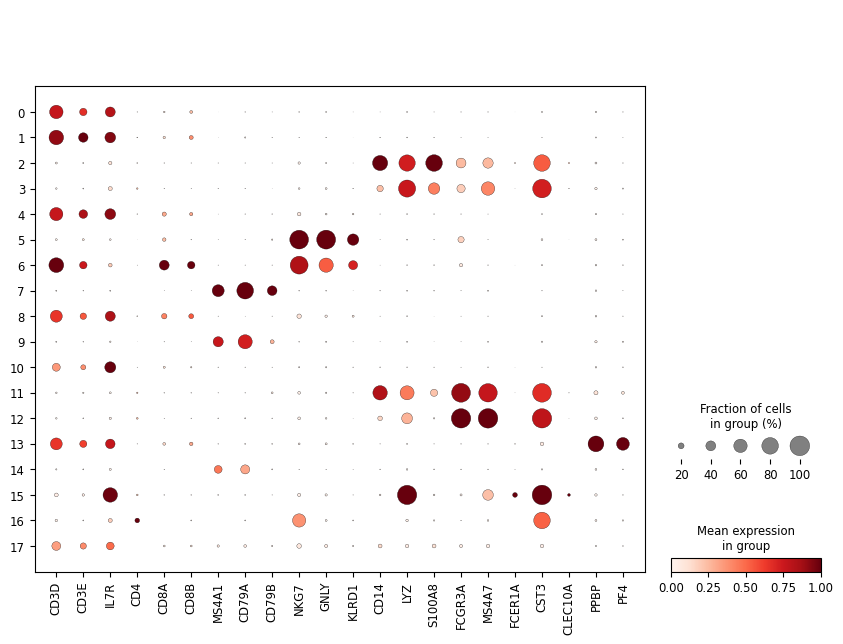

<Figure size 640x480 with 0 Axes>

In [6]:
all_markers = sum(marker_sets.values(), [])
all_markers_present = [g for g in dict.fromkeys(all_markers) if g in adata_full.var_names]

sc.pl.dotplot(adata_full, all_markers_present, groupby="leiden", standard_scale="var")
plt.savefig("../figures/fig2_marker_dotplot.png", dpi=150, bbox_inches="tight")
plt.show()

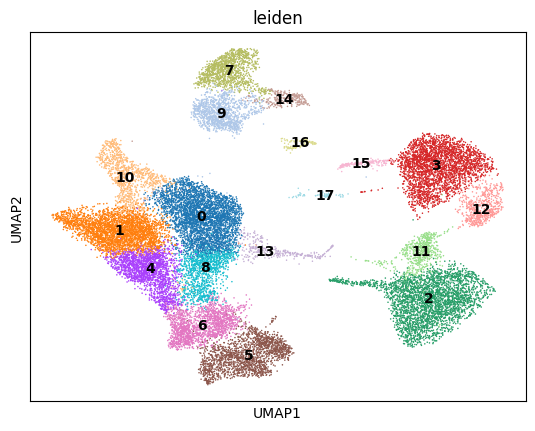

In [7]:
sc.pl.umap(adata_full, color=["leiden"], legend_loc="on data")
plt.show()

## Save checkpoint

In [8]:
cluster_to_identity = proposed_identity.to_dict()
adata_full.obs["proposed_cell_type"] = adata_full.obs["leiden"].map(cluster_to_identity)

adata_full.write("../results/adata_annotated.h5ad")
comparison.to_csv("../results/cluster_annotation_comparison.csv")
print("Saved: results/adata_annotated.h5ad and results/cluster_annotation_comparison.csv")

Saved: results/adata_annotated.h5ad and results/cluster_annotation_comparison.csv
